# ДЗ 1. Измерение стоимости CNN


## Требования к оборудованию
- Python 3.10+ и установленный PyTorch с поддержкой CUDA
- Одна NVIDIA GPU с CUDA: T4 или P100 в Colab/Kaggle
- Для локальной NVIDIA GPU объём памяти не более 16 ГБ
- При нескольких доступных GPU используется только `cuda:0`
- Для энергии необходим доступ к NVML: счетчику энергии либо мощности

## Подготовка
В Colab выберите среду с GPU, в Kaggle включите GPU accelerator
Скопируйте рядом с ноутбуком `models.py`, `equations.py`, `calibrate.py`
При запуске из корня репозитория файлы автоматически грузятся в `hw1/`
Результаты сохраняются в текущую рабочую папку, поэтому папка с кодом может быть read-only


In [1]:
%pip install -q "numpy>=1.26" pandas scipy matplotlib nvidia-ml-py


In [2]:
import gc
import json
import platform
import sys
from pathlib import Path
from threading import Event, Thread
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynvml
import scipy
import torch
from IPython.display import display
from torch import nn

CODE_DIR = Path.cwd()
if not (CODE_DIR / "models.py").exists():
    CODE_DIR = CODE_DIR / "hw1"
if not all((CODE_DIR / name).exists() for name in
           ("models.py", "equations.py", "calibrate.py")):
    raise FileNotFoundError("Укажите CODE_DIR с тремя .py-файлами")
sys.path.insert(0, str(CODE_DIR.resolve()))

from models import SmallCNN
from equations import flops, memory, latency, energy
from calibrate import calibrate

RESULTS = Path.cwd() / "results"
SEED = 42
WARMUP = 10
REPEATS = 30
ENERGY_SECONDS = 3.0
POWER_INTERVAL = 0.05


## 1. Окружение и настройки


In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError("Нужна NVIDIA GPU: включите GPU в Colab/Kaggle")

torch.cuda.set_device(0)
device = torch.device("cuda:0")
props = torch.cuda.get_device_properties(device)
if props.total_memory > 16 * 1024**3:
    raise RuntimeError(
        "GPU больше 16 Gib: выберите T4/P100 или согласуйте замену"
    )

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.manual_seed(SEED)

if (RESULTS / "measurements.csv").exists():
    raise FileExistsError(
        "Результаты уже существуют. Сохраните их и выберите новую RESULTS "
        "для нового запуска, для анализа используйте раздел 5."
    )
RESULTS.mkdir(parents=True, exist_ok=True)
(RESULTS / "figures").mkdir(exist_ok=True)

handle = None
energy_method = "unavailable"
energy_error = ""
try:
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByUUID(str(props.uuid))
    try:
        pynvml.nvmlDeviceGetTotalEnergyConsumption(handle)
        energy_method = "nvml_counter"
    except pynvml.NVMLError:
        pynvml.nvmlDeviceGetPowerUsage(handle)
        energy_method = "nvml_power"
except (pynvml.NVMLError, AttributeError) as exc:
    energy_error = str(exc)
    print("Энергия недоступна. Эта часть ДЗ останется незавершенной:", exc)

environment = {
    "gpu": props.name,
    "gpu_uuid": str(getattr(props, "uuid", "unknown")),
    "gpu_memory_bytes": props.total_memory,
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "pandas": pd.__version__,
    "seed": SEED,
    "warmup": WARMUP,
    "repeats": REPEATS,
    "energy_seconds": ENERGY_SECONDS,
    "power_interval": POWER_INTERVAL,
    "energy_method": energy_method,
    "energy_error": energy_error,
    "cudnn_benchmark": False,
    "cudnn_allow_tf32": False,
    "matmul_allow_tf32": False,
}
if handle is not None:
    environment["driver"] = pynvml.nvmlSystemGetDriverVersion()
(RESULTS / "environment.json").write_text(
    json.dumps(environment, indent=2), encoding="utf-8"
)
display(environment)
model = SmallCNN().to(device=device, dtype=torch.float32).eval()
assert sum(p.numel() for p in model.parameters()) == 1_040_324


{'gpu': 'Tesla T4',
 'gpu_uuid': '3ac277c6-f569-d549-71b6-a67afa0ccc77',
 'gpu_memory_bytes': 15637086208,
 'python': '3.13.15',
 'torch': '2.11.0+cu128',
 'cuda': '12.8',
 'cudnn': 91900,
 'numpy': '2.1.3',
 'scipy': '1.16.3',
 'pandas': '2.2.3',
 'seed': 42,
 'warmup': 10,
 'repeats': 30,
 'energy_seconds': 3.0,
 'power_interval': 0.05,
 'energy_method': 'nvml_counter',
 'energy_error': '',
 'cudnn_benchmark': False,
 'cudnn_allow_tf32': False,
 'matmul_allow_tf32': False,
 'driver': '580.82.07'}

## 2. Сетка и разделение данных

Все 63 пары базовой сетки — калибровка. Остальные 69 пар, содержащие новый S или B,
— проверка (`is_validation=True`). Разделение фиксируется до измерений.
Дополнительные значения выбираются без повторов. Порядок запусков перемешан.


In [4]:
rng = np.random.default_rng(SEED)
base_sizes = [32, 64, 128, 224, 256, 384, 512]
base_batches = [1, 2, 4, 8, 16, 32, 64, 128, 256]
extra_sizes = rng.choice(
    [s for s in range(32, 513, 16) if s not in base_sizes],
    size=4, replace=False,
).tolist()
extra_batches = rng.choice(
    [b for b in range(1, 257) if b not in base_batches],
    size=3, replace=False,
).tolist()
sizes = sorted(base_sizes + extra_sizes)
batches = sorted(base_batches + extra_batches)
grid = pd.DataFrame([
    {"S": s, "B": b,
     "is_validation": s not in base_sizes or b not in base_batches}
    for s in sizes for b in batches
])
assert len(grid) == 132 and grid["is_validation"].sum() == 69
grid = grid.sample(frac=1, random_state=SEED).reset_index(drop=True)
grid.to_csv(RESULTS / "grid.csv", index=False)
print("S:", sizes, "\nB:", batches)


S: [32, 64, 80, 128, 224, 256, 272, 352, 384, 400, 512] 
B: [1, 2, 4, 8, 16, 29, 32, 56, 64, 128, 179, 256]


## 3. Протокол измерений

- Вход создаётся сразу на GPU, генерация не входит в latency.
- После прогрева измеряем 30 отдельных forward через `perf_counter` с CUDA-синхронизацией
  Берём медиану. Это wall-clock время с расходами Python и синхронизации
- Память измеряется отдельно: сбрасываем статистику пика и выполняем один forward
  Учитываются параметры, вход и выход; базовая память не вычитается
- Энергия: выполняем серию проходов не менее 3 с. Разность счетчика NVML в мДж
  переводим в джоули и делим на число проходов. Если счетчик недоступен,
  интегрируем показания мощности NVML (мВт → Вт), опрашивая их в отдельном потоке
  Мощность простоя не вычитается. Это средняя энергия прохода в серии,
  накладные расходы серии и разрешение телеметрии дают погрешность.
- FLOPs проверяем отдельным подсчётом по реально выполненным слоям и формам тензоров.
  Это проверка реализации, **не измерение аппаратных инструкций GPU**.
- OOM сохраняется с названием стадии, никакие большие конфигурации заранее не пропускаются.

Справка: [NVML](https://docs.nvidia.com/deploy/nvml-api/api/group__nvmlDeviceQueries.html),
[CUDA и синхронизация](https://docs.pytorch.org/docs/stable/notes/cuda.html).


In [6]:
def measure_energy(x):
    if energy_method == "unavailable":
        return {"energy": np.nan, "energy_passes": 0,
                "energy_duration": np.nan, "energy_error": energy_error}

    samples, errors = [], []
    stop = Event()

    def sample_power():
        samples.append((perf_counter(),
                        pynvml.nvmlDeviceGetPowerUsage(handle) / 1000))

    def poll_power():
        while not stop.wait(POWER_INTERVAL):
            try:
                sample_power()
            except pynvml.NVMLError as exc:
                errors.append(str(exc))
                break

    worker = None
    try:
        torch.cuda.synchronize()
        if energy_method == "nvml_counter":
            start_energy = pynvml.nvmlDeviceGetTotalEnergyConsumption(handle)
        else:
            sample_power()
            worker = Thread(target=poll_power, daemon=True)
            worker.start()
        start = perf_counter()
        count = 0
        while True:
            for _ in range(10):
                output = model(x)
                del output
                count += 1
            torch.cuda.synchronize()
            if perf_counter() - start >= ENERGY_SECONDS:
                break
        duration = perf_counter() - start
        if energy_method == "nvml_counter":
            end_energy = pynvml.nvmlDeviceGetTotalEnergyConsumption(handle)
            joules = (end_energy - start_energy) / 1000
        else:
            stop.set()
            worker.join()
            sample_power()
            if errors:
                raise RuntimeError(errors[0])
            times, watts = np.asarray(samples).T
            mean_watts = (watts[1:] + watts[:-1]) / 2
            joules = float(np.sum(np.diff(times) * mean_watts))
        if not np.isfinite(joules) or joules <= 0:
            raise RuntimeError("NVML не зарегистрировал положительную энергию")
        return {"energy": joules / count, "energy_passes": count,
                "energy_duration": duration, "energy_error": ""}
    except (pynvml.NVMLError, RuntimeError) as exc:
        if isinstance(exc, torch.cuda.OutOfMemoryError):
            raise
        return {"energy": np.nan, "energy_passes": 0,
                "energy_duration": np.nan, "energy_error": str(exc)}
    finally:
        stop.set()
        if worker is not None:
            worker.join()


def count_forward_flops(x):
    counts = []

    def count(module, inputs, output):
        if isinstance(module, nn.Conv2d):
            kernel = module.kernel_size[0] * module.kernel_size[1]
            counts.append(2 * output.numel() * module.in_channels * kernel)
        elif isinstance(module, nn.Linear):
            counts.append(output.numel() * (2 * module.in_features + 1))
        elif isinstance(module, nn.AdaptiveAvgPool2d):
            counts.append(inputs[0].numel())

    counted_types = (nn.Conv2d, nn.Linear, nn.AdaptiveAvgPool2d)
    hooks = [layer.register_forward_hook(count)
             for layer in model.modules() if isinstance(layer, counted_types)]
    try:
        output = model(x)
        del output
        torch.cuda.synchronize()
    finally:
        for hook in hooks:
            hook.remove()
    return sum(counts)


def measure_configuration(size, batch):
    result = {"status": "OK", "stage": "input", "latency": np.nan,
              "memory": np.nan, "energy": np.nan,
              "flops_reference": np.nan, "energy_error": ""}
    x = output = None
    gc.collect()
    torch.cuda.empty_cache()
    result["free_bytes_before"] = torch.cuda.mem_get_info()[0]
    try:
        with torch.inference_mode():
            x = torch.randn(
                batch, 3, size, size, device=device, dtype=torch.float32
            )
            result["stage"] = "warmup"
            for _ in range(WARMUP):
                output = model(x)
                del output
            torch.cuda.synchronize()

            result["stage"] = "memory"
            torch.cuda.reset_peak_memory_stats()
            output = model(x)
            torch.cuda.synchronize()
            result["memory"] = torch.cuda.max_memory_allocated()
            del output

            result["stage"] = "latency"
            times = []
            for _ in range(REPEATS):
                torch.cuda.synchronize()
                start = perf_counter()
                output = model(x)
                torch.cuda.synchronize()
                times.append(perf_counter() - start)
                del output
            result["latency"] = float(np.median(times))

            result["stage"] = "flops"
            result["flops_reference"] = count_forward_flops(x)
            result["stage"] = "energy"
            result.update(measure_energy(x))
            result["stage"] = "done"
    except torch.cuda.OutOfMemoryError:
        result["status"] = "OOM"
    finally:
        x = output = None
        gc.collect()
        torch.cuda.empty_cache()
    return result


## 4. Измерения всей сетки

Сначала можно отдельно выполнить `measure_configuration(32, 1)` для проверки среды.
Следующая ячейка запускает все 132 конфигурации и сохраняет CSV после каждой.
При прерывании уже сохраненные строки остаются на диске. Новый полный запуск
делайте в новой папке RESULTS, чтобы не смешивать окружения.


In [7]:
rows = []
for config in grid.to_dict("records"):
    measured = measure_configuration(config["S"], config["B"])
    rows.append({**config, **measured, "energy_method": energy_method})
    pd.DataFrame(rows).to_csv(RESULTS / "measurements.csv", index=False)
    print(f"{len(rows):3}/132: S={config['S']}, B={config['B']}: "
          f"{measured['status']}", flush=True)
measurements = pd.DataFrame(rows)
display(measurements.head())
print(measurements["status"].value_counts())


  1/132: S=224, B=64: OK
  2/132: S=272, B=256: OK
  3/132: S=64, B=56: OK
  4/132: S=80, B=56: OK
  5/132: S=272, B=16: OK
  6/132: S=400, B=128: OK
  7/132: S=224, B=56: OK
  8/132: S=512, B=64: OK
  9/132: S=256, B=16: OK
 10/132: S=80, B=4: OK
 11/132: S=128, B=64: OK
 12/132: S=80, B=8: OK
 13/132: S=128, B=256: OK
 14/132: S=32, B=16: OK
 15/132: S=384, B=4: OK
 16/132: S=384, B=29: OK
 17/132: S=128, B=1: OK
 18/132: S=272, B=128: OK
 19/132: S=128, B=16: OK
 20/132: S=256, B=4: OK
 21/132: S=64, B=32: OK
 22/132: S=32, B=179: OK
 23/132: S=128, B=32: OK
 24/132: S=32, B=256: OK
 25/132: S=400, B=1: OK
 26/132: S=256, B=29: OK
 27/132: S=512, B=56: OK
 28/132: S=352, B=256: OK
 29/132: S=384, B=1: OK
 30/132: S=32, B=1: OK
 31/132: S=64, B=1: OK
 32/132: S=512, B=32: OK
 33/132: S=256, B=179: OK
 34/132: S=80, B=1: OK
 35/132: S=272, B=64: OK
 36/132: S=400, B=32: OK
 37/132: S=224, B=8: OK
 38/132: S=64, B=8: OK
 39/132: S=272, B=32: OK
 40/132: S=256, B=64: OK
 41/132: S=64, B

,S,B,is_validation,status,stage,latency,memory,energy,flops_reference,energy_error,free_bytes_before,energy_passes,energy_duration,energy_method
0,224,64,False,OK,done,0.015188,335904768,1.072925,56904407296,,15504048128,200,3.030869,nvml_counter
1,272,256,True,OK,done,0.140756,1761968128,9.572767,335581766656,,15472590848,30,4.240772,nvml_counter
2,64,56,True,OK,done,0.001129,29327360,0.088436,4080733664,,15472590848,2330,3.006136,nvml_counter
3,80,56,True,OK,done,0.002012,38100992,0.147009,6366264800,,15472590848,1400,3.003219,nvml_counter
4,272,16,True,OK,done,0.005972,125280256,0.394221,20973860416,,15472590848,520,3.054259,nvml_counter


status
OK    132
Name: count, dtype: int64


## 5. Калибровка

Подбираем параметры по строкам `is_validation=False`, статус OK.
Минимизируем квадраты логарифмов отношений прогноза времени к измерению:
так малые и большие конфигурации имеют сопоставимый вес.
Используем три начальных приближения. Положительность обеспечивается
логарифмической параметризацией. Средняя мощность подбирается по тому же
критерию для энергии с уже зафиксированной моделью времени.


In [8]:
measurements = pd.read_csv(RESULTS / "measurements.csv")
if len(measurements) != 132:
    print(f"Сетка не завершена: сохранено {len(measurements)} из 132 строк.")
missing_energy = (
    measurements["status"].eq("OK") & measurements["energy"].isna()
).sum()
if missing_energy:
    print(f"Нет энергии для {missing_energy} успешных конфигураций.")
fit = calibrate(measurements)
(RESULTS / "theta.json").write_text(
    json.dumps(fit, indent=2, allow_nan=False), encoding="utf-8"
)
display(fit)
if fit["energy"] is None:
    print("Энергетическая часть не завершена: нет измерений для калибровки.")


{'latency': {'t0': 0.00035922474216989667,
  'p_eff': 5735192116282.01,
  'bw_eff': 78407874149.93254},
 'energy': {'t0': 0.00035922474216989667,
  'p_eff': 5735192116282.01,
  'bw_eff': 78407874149.93254,
  'power': 66.44753826819948},
 'calibration_rows': 63,
 'energy_calibration_rows': 63,
 'latency_log_rmse': 0.27895265679542774}

## 6. Прогнозы и ошибки на отложенных точках

Memory использует сумму активаций.
Проверка FLOPs по исполненным слоям не является аппаратным измерением.


In [9]:
results = measurements.copy()
s = results["S"].to_numpy()
b = results["B"].to_numpy()
results["flops_predicted"] = flops(s, b)
results["memory_predicted"] = memory(s, b)
results["latency_predicted"] = latency(s, b, fit["latency"])
results["energy_predicted"] = (
    energy(s, b, fit["energy"]) if fit["energy"] is not None else np.nan
)
valid = results["is_validation"].astype(str).str.lower().eq("true")
ok = results["status"].eq("OK")
metrics = []
for metric in ["memory", "latency", "energy"]:
    subset = results.loc[valid & ok].dropna(
        subset=[metric, metric + "_predicted"]
    )
    if subset.empty:
        continue
    relative = (subset[metric + "_predicted"] / subset[metric] - 1).abs()
    metrics.append({"metric": metric, "validation_points": len(subset),
                    "MAPE_percent": 100 * relative.mean(),
                    "max_error_percent": 100 * relative.max()})
results.to_csv(RESULTS / "predictions.csv", index=False)
metrics = pd.DataFrame(metrics)
metrics.to_csv(RESULTS / "metrics.csv", index=False)
display(metrics)
checked = results["flops_reference"].notna()
np.testing.assert_allclose(
    results.loc[checked, "flops_reference"],
    results.loc[checked, "flops_predicted"], rtol=0, atol=0,
)
print("FLOPs совпадают с подсчётом по исполненным слоям.")


,metric,validation_points,MAPE_percent,max_error_percent
0,memory,69,16.812308,79.917594
1,latency,69,20.658414,62.528124
2,energy,69,17.038919,53.707869


FLOPs совпадают с подсчётом по исполненным слоям.


## 7. Графики

Для каждого S строим срез по B: линия — прогноз, точки — измерения.
Для FLOPs точки показывают проверочный подсчет по слоям.
Пустые энергетические результаты не заменяются прогнозом


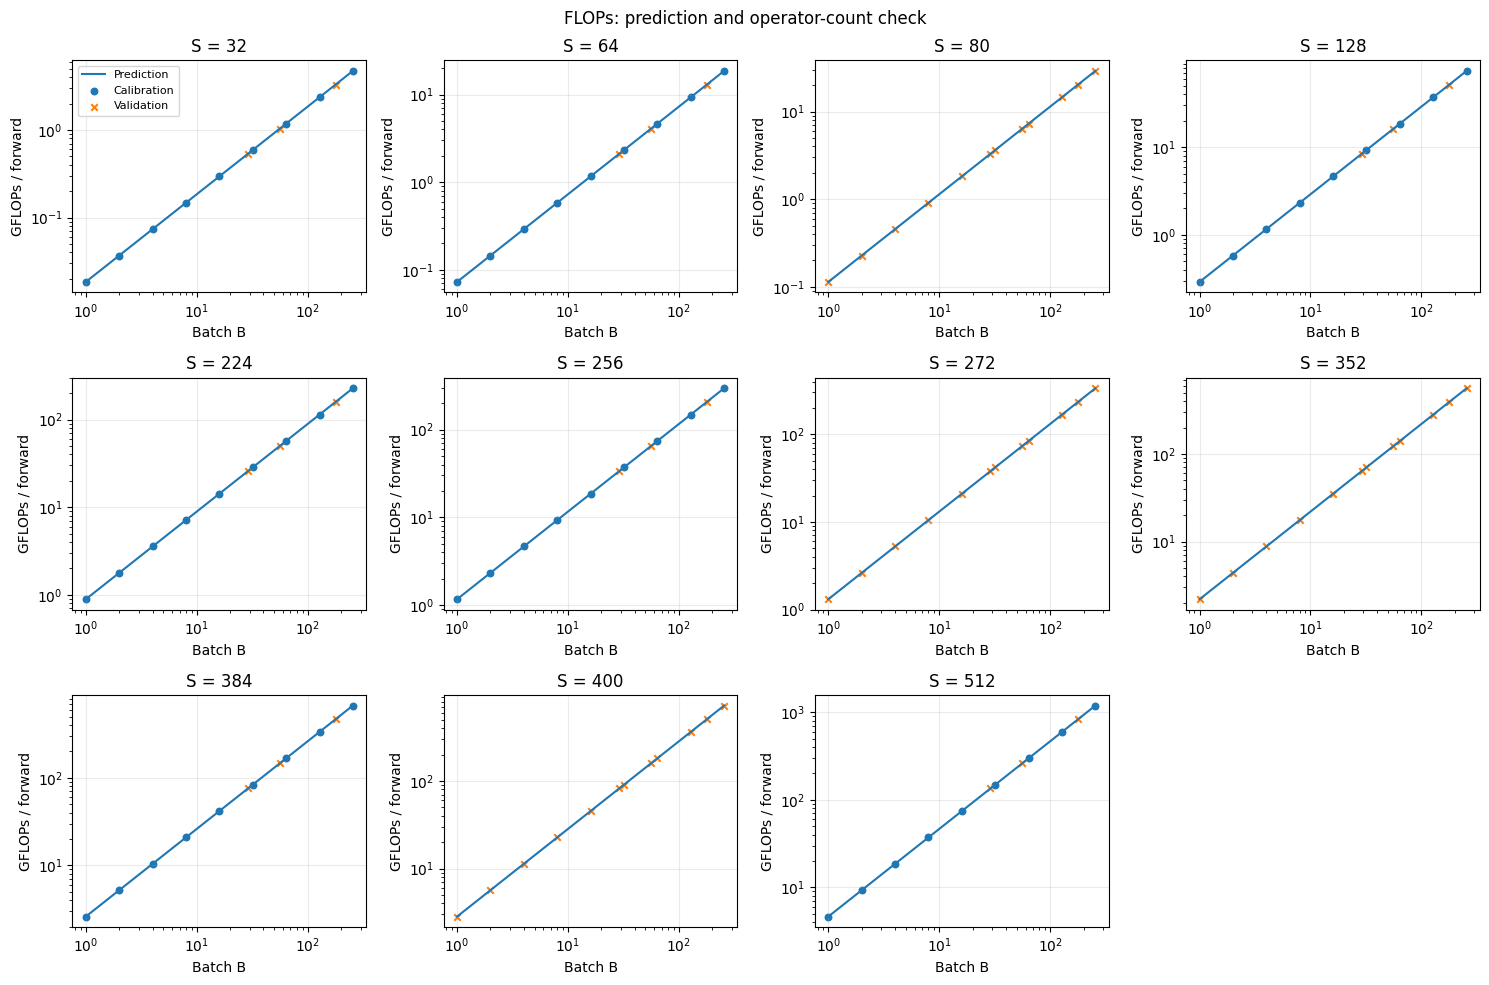

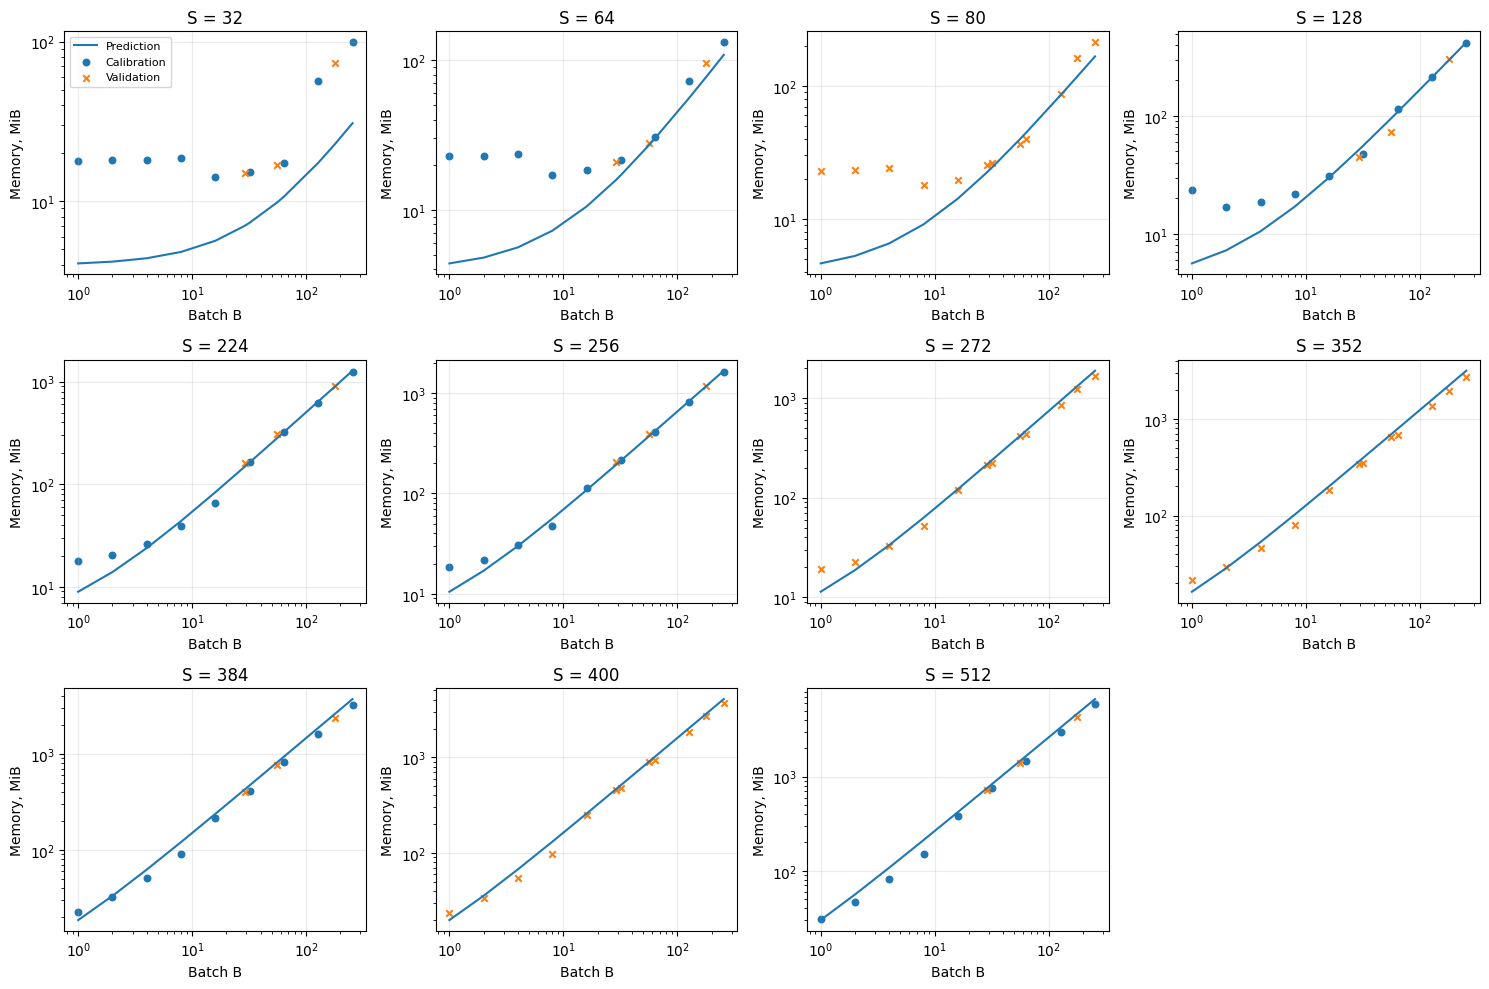

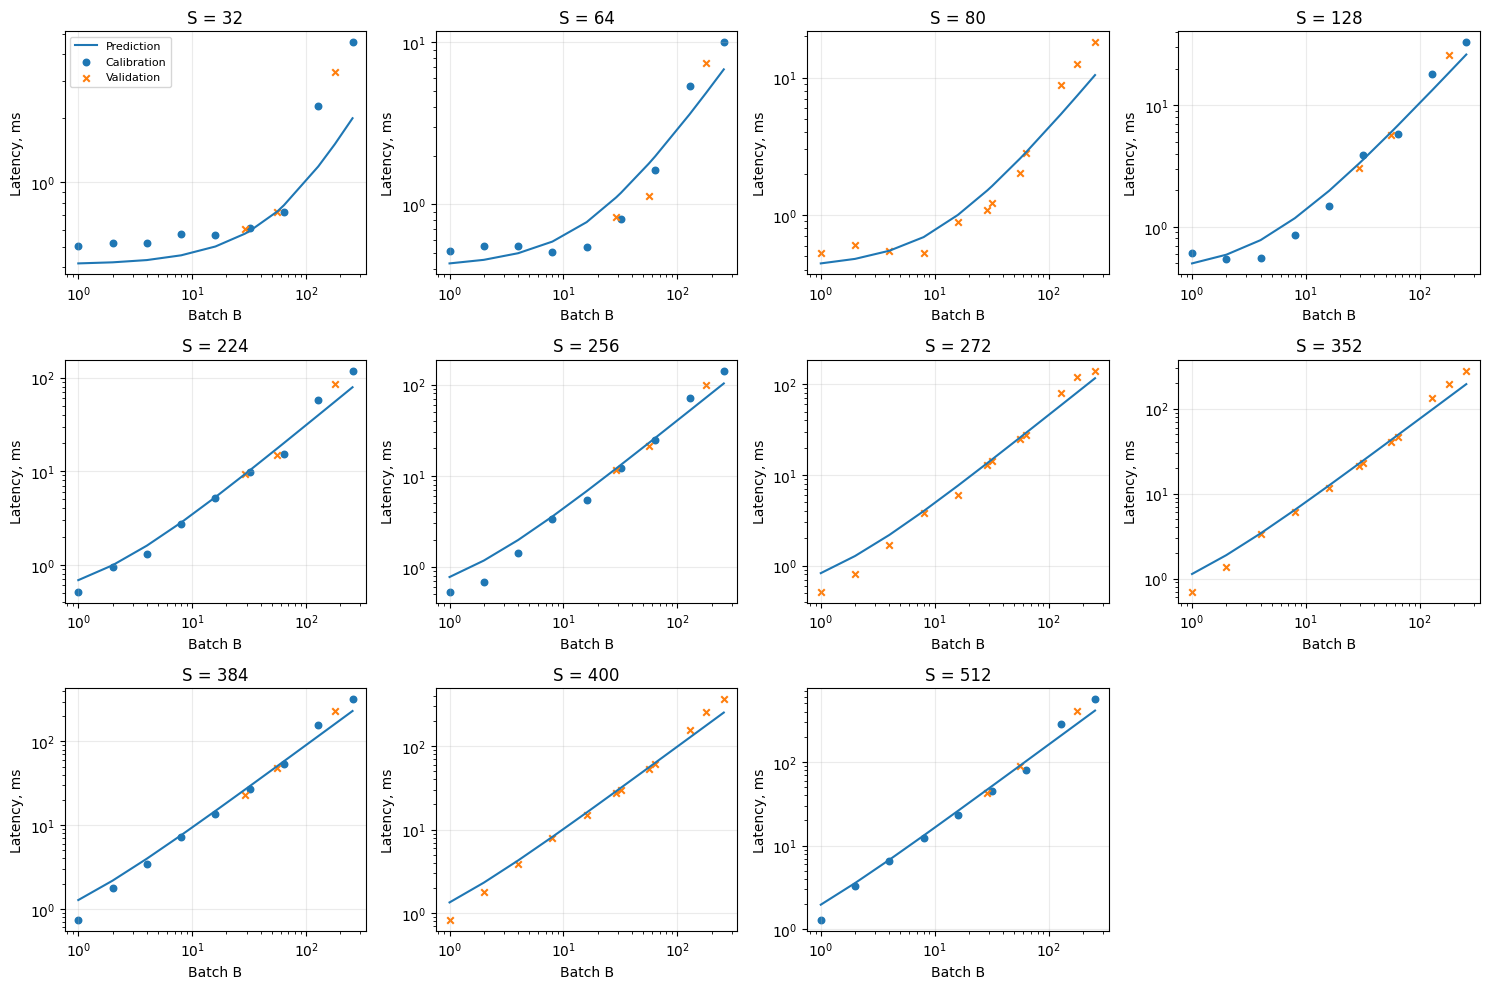

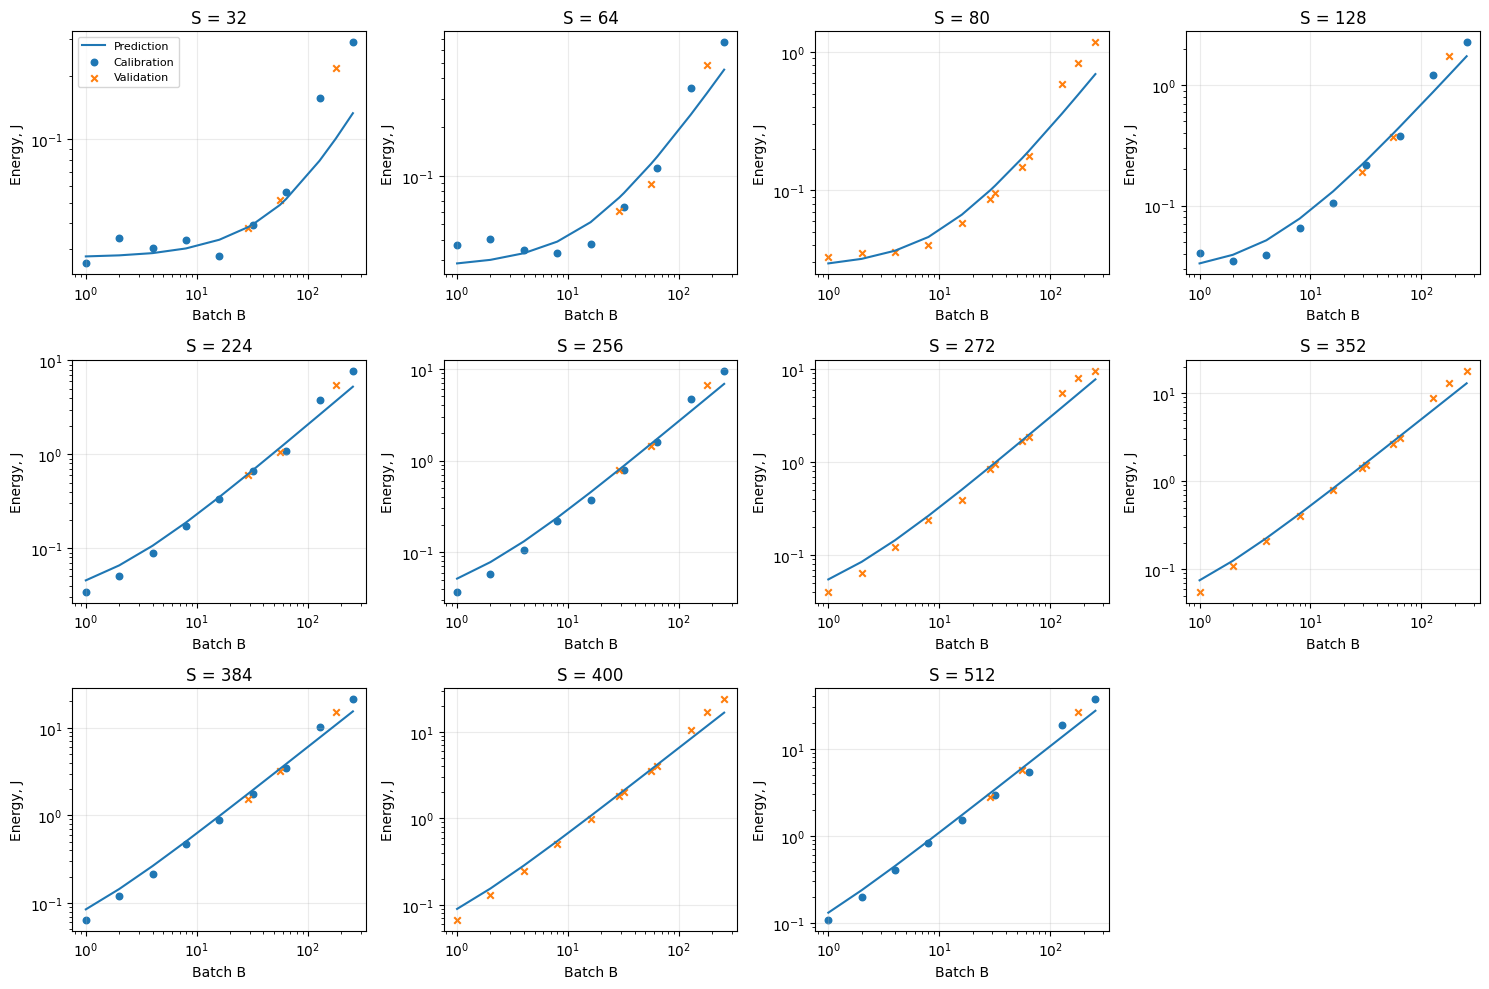

In [10]:
plot_specs = [
    ("flops", "flops_reference", 1e9, "GFLOPs / forward"),
    ("memory", "memory", 1024**2, "Memory, MiB"),
    ("latency", "latency", 1e-3, "Latency, ms"),
    ("energy", "energy", 1, "Energy, J"),
]
for name, observed, scale, ylabel in plot_specs:
    if results[observed].notna().sum() == 0:
        print(f"Нет данных для графика {name}")
        continue
    fig, axes = plt.subplots(3, 4, figsize=(15, 10), squeeze=False)
    for ax, size in zip(axes.flat, sorted(results["S"].unique())):
        part = results.loc[results["S"].eq(size)].sort_values("B")
        ax.plot(part["B"], part[name + "_predicted"] / scale,
                label="Prediction")
        for is_valid, marker, label in [(False, "o", "Calibration"),
                                         (True, "x", "Validation")]:
            mask = part["is_validation"].astype(str).str.lower().eq(
                str(is_valid).lower()
            ) & part["status"].eq("OK")
            points = part.loc[mask].dropna(subset=[observed])
            ax.scatter(points["B"], points[observed] / scale,
                       marker=marker, label=label, s=22)
        ax.set(xscale="log", yscale="log", xlabel="Batch B",
               ylabel=ylabel, title=f"S = {size}")
        ax.grid(alpha=0.25)
    for ax in axes.flat[len(results["S"].unique()):]:
        ax.set_visible(False)
    axes.flat[0].legend(fontsize=8)
    if name == "flops":
        fig.suptitle("FLOPs: prediction and operator-count check")
    fig.tight_layout()
    fig.savefig(RESULTS / "figures" / f"{name}.png", dpi=150)
    plt.show()
    plt.close(fig)


## 8. OOM и ограничения модели

Для грубого прогноза OOM сравниваем memory(S,B) с доступным перед конфигурацией
объемом плюс уже выделенная память параметров. Это не точный критерий:
формула суммирует активации и не учитывает workspace, кеш аллокатора и фрагментацию.


Measured OOM,False
Predicted OOM,
False,132


,S,B,stage,memory_predicted,status


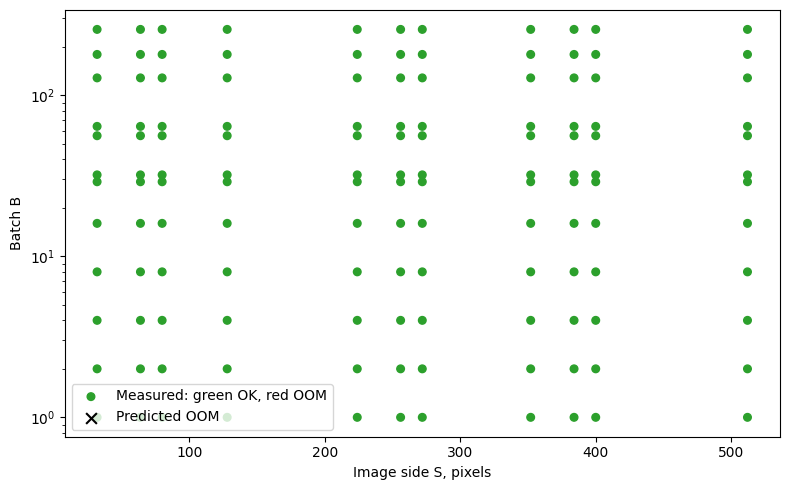

In [11]:
parameter_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
results["oom_predicted"] = results["memory_predicted"] > (
    results["free_bytes_before"] + parameter_bytes
)
results["oom_measured"] = results["status"].eq("OOM")
results.to_csv(RESULTS / "predictions.csv", index=False)
display(pd.crosstab(results["oom_predicted"], results["oom_measured"],
                    rownames=["Predicted OOM"], colnames=["Measured OOM"]))
display(results.loc[results["oom_predicted"] != results["oom_measured"],
                    ["S", "B", "stage", "memory_predicted", "status"]])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results["S"], results["B"],
           c=np.where(results["oom_measured"], "tab:red", "tab:green"),
           label="Measured: green OK, red OOM", s=30)
predicted_oom = results.loc[results["oom_predicted"]]
ax.scatter(predicted_oom["S"], predicted_oom["B"], marker="x",
           c="black", label="Predicted OOM", s=60)
ax.set(xlabel="Image side S, pixels", ylabel="Batch B", yscale="log")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "figures" / "oom.png", dpi=150)
plt.show()
plt.close(fig)
